<a href="https://colab.research.google.com/github/prpNn0p/image-classification/blob/main/DeepFont_predict_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gdown --id 1xwb3udG7Lv_r7ksclUQjZridZ8-eA-Fl

Downloading...
From: https://drive.google.com/uc?id=1xwb3udG7Lv_r7ksclUQjZridZ8-eA-Fl
To: /content/the_best_model_in_the_world_ver4_wbg_cleaned_garbage_data.h5
100% 755M/755M [00:06<00:00, 116MB/s]


In [ ]:
!gdown --id 1-4FvS9DJvsYk9NQ7TUNsElVDiR5OA264

Downloading...
From: https://drive.google.com/uc?id=1-4FvS9DJvsYk9NQ7TUNsElVDiR5OA264
To: /content/testwhite1.zip
100% 150M/150M [00:04<00:00, 34.3MB/s]


In [ ]:
!unzip -qq '/content/testwhite1.zip'

In [ ]:
from matplotlib.pyplot import imshow
import matplotlib.cm as cm
import matplotlib.pylab as plt
from keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import PIL
from PIL import ImageFilter
import cv2
import itertools
import random
import keras
import imutils
from imutils import paths
import os
from keras import optimizers
from keras.preprocessing.image import img_to_array
from sklearn.model_selection import train_test_split
#from keras.utils import to_categorical
from tensorflow.keras.utils import to_categorical
from keras import callbacks
from keras.models import Sequential
#from keras.layers.normalization import BatchNormalization
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D , UpSampling2D ,Conv2DTranspose
from keras import backend as K
import tensorflow as tf


%matplotlib inline

In [ ]:
from keras.models import load_model
model = load_model('/content/the_best_model_in_the_world_ver4_wbg_cleaned_garbage_data.h5')

In [ ]:
# test_image_path = '/content/image.png'
# test_json_path = '/content/test.json'

In [ ]:
def convert(image_path):
  image = cv2.imread(image_path)
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  ths = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 4)
  image_side = max(ths.shape[0], ths.shape[1])
  if image_side > 105:
    crop_ths = ths[:105, :105]
  else:
    crop_ths = ths
  result = np.full((105,105), 0, dtype=np.uint8)

  # compute center offset
  x_center = (105 - crop_ths.shape[1]) // 2
  y_center = (105 - crop_ths.shape[0]) // 2

  # copy img image into center of result image
  result[y_center:y_center+crop_ths.shape[0], x_center:x_center+crop_ths.shape[1]] = crop_ths
  resize = cv2.resize(result, (105, 105))
  return resize

In [ ]:
def rev_conv_fam(label):
    if label == 0: #'ANGSA.ttf'
        return 'Angsana_New'
    elif label == 1: #'CORDIA.ttf'
        return 'Cordia_New'
    elif label == 2: #'DM Shining Star Regular.ttf'
        return 'DM_Shining_Star_Regular'
    elif label == 3: #'FC Knomphing Regular.ttf'
        return 'FC_Knomphing_Regular'
    elif label == 4: #fonttintin.ttf'
        return 'fonttintin'
    elif label == 5:
        return 'Kunlasatri'
    elif label == 6:
        return 'TH_Chakra_Petch'
    elif label == 7:
        return 'TH_Charm_of_AU'
    elif label == 8:
        return 'TH_Mali_Grade6'
    elif label == 9:
        return 'TH_Sarabun'
    
    #to_label = [0 for i in range(10)]
    #to_label[index] = 1

In [ ]:
def rev_conv_file(label):
    if label == 'Angsana_New': #'ANGSA.ttf'
        return 'ANGSA.ttf'
    elif label == 'Cordia_New': #'CORDIA.ttf'
        return 'CORDIA.ttf'
    elif label == 'DM_Shining_Star_Regular': #'DM Shining Star Regular.ttf'
        return 'DM Shining Star Regular.ttf'
    elif label == 'FC_Knomphing_Regular': #'FC Knomphing Regular.ttf'
        return 'FC Knomphing Regular.ttf'
    elif label == 'fonttintin': #fonttintin.ttf'
        return 'fonttintin.ttf'
    elif label == 'Kunlasatri':
        return 'Kunlasatri.ttf'
    elif label == 'TH_Chakra_Petch':
        return 'TH Chakra Petch.ttf'
    elif label == 'TH_Charm_of_AU':
        return 'TH Charm of AU.ttf'
    elif label == 'TH_Mali_Grade6':
        return 'TH Mali Grade6.ttf'
    elif label == 'TH_Sarabun':
        return 'THSarabun.ttf'
    
    #to_label = [0 for i in range(10)]
    #to_label[index] = 1

In [ ]:
# def conv_fonts(label):
#   name = ['ANGSA.ttf', 'CORDIA.ttf', 'DM Shining Star Regular.ttf', 'FC Knomphing Regular.ttf', 'fonttintin.ttf', 'Kunlasatri.ttf', 'TH Chakra Petch.ttf', 'TH Charm of AU.ttf', 'TH Mali Grade6.ttf', 'THSarabun.ttf']    
#   return name[label]

In [ ]:
def rev_conv_style(label):
    if label == 0:
        return 'normal-normal'
    elif label == 1:
        return 'italic-normal'
    elif label == 2:
        return 'normal-bold'
    elif label == 3:
        return 'italic-bold'

In [ ]:
def rev_conv_size(label):
    if label == 0:
        return '12px'
    elif label == 1:
        return '14px'
    elif label == 2:
        return '16px'
    elif label == 3:
        return '18px'
    elif label == 4:
        return '20px'
    elif label == 5:
        return '22px'
    elif label == 6:
        return '24px'

In [ ]:
path_testing = sorted(os.listdir('/content/testwhite1'))
path_testing[:5]

['0000144b.jpg',
 '00013eaf.jpg',
 '00024a7a.jpg',
 '0004eae6.jpg',
 '00066fea.jpg']

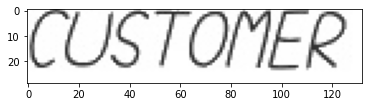

In [ ]:
pathx = '/content/testwhite1/00066fea.jpg'
imgx = cv2.imread(pathx)
plt.imshow(imgx)

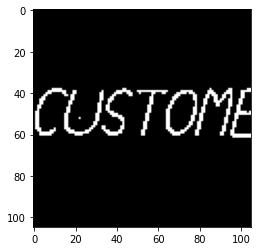

In [ ]:
testing = convert('/content/testwhite1/00066fea.jpg')
plt.imshow(testing, cmap='gray')

In [ ]:
testing.shape

(105, 105)

In [ ]:
data_path = "/content/testwhite1/"
data=[]
labels=[]
imagePaths = sorted(list(paths.list_images(data_path)))

In [ ]:
imagePaths[:20]

['/content/testwhite1/0000144b.jpg',
 '/content/testwhite1/00013eaf.jpg',
 '/content/testwhite1/00024a7a.jpg',
 '/content/testwhite1/0004eae6.jpg',
 '/content/testwhite1/00066fea.jpg',
 '/content/testwhite1/0008d204.jpg',
 '/content/testwhite1/0008fc86.jpg',
 '/content/testwhite1/000aa2e3.jpg',
 '/content/testwhite1/000af286.jpg',
 '/content/testwhite1/000b3f13.jpg',
 '/content/testwhite1/000f69ab.jpg',
 '/content/testwhite1/000facb2.jpg',
 '/content/testwhite1/0011426e.jpg',
 '/content/testwhite1/0011b14c.jpg',
 '/content/testwhite1/00123f98.jpg',
 '/content/testwhite1/00126a3b.jpg',
 '/content/testwhite1/001284ee.jpg',
 '/content/testwhite1/0012d5c0.jpg',
 '/content/testwhite1/00134fc6.jpg',
 '/content/testwhite1/0013c16e.jpg']

In [ ]:
counter=0
for imagePath in imagePaths:
    #labelx = imagePath.split(os.path.sep)[-1]  #os.path.basename(file).split('-', 2)[1]
    #label = labelx.split('-', 2)[1]
    #label = conv_label(label)
    converted_img = convert(imagePath)
    #imshow(pil_img)
    
    # Adding original image
    #org_img = img_to_array(pil_img, dtype='uint8')
    data.append(converted_img)
    #labels.append(label)

In [ ]:
len(data)

48251

In [ ]:
#deno = 255
data = np.array(data, dtype='uint8')
#labels = np.array(labels)
print("Success")
# partition the data into training and testing splits using 75% of
# the data for training and the remaining 25% for testing
#(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.25, random_state=42)

Success


In [ ]:
predict_x = model.predict(data)
fonts_x = np.argmax(predict_x[0],axis=1)
styles_x = np.argmax(predict_x[1],axis=1)
sizes_x = np.argmax(predict_x[2],axis=1)

In [ ]:
# y_pred = logreg.predict(X)#Get the confusion matrix
# cf_matrix = confusion_matrix(y, y_pred)
# print(cf_matrix)

In [ ]:
fonts_x[:4]
#array([3, 7, 1, ..., 1, 4, 5])

array([4, 7, 9, 9])

In [ ]:
fonts_x = fonts_x.tolist()
styles_x = styles_x.tolist()
sizes_x = sizes_x.tolist()

In [ ]:
styles_x

[1,
 3,
 1,
 0,
 1,
 1,
 2,
 2,
 3,
 1,
 3,
 2,
 3,
 0,
 2,
 1,
 0,
 1,
 1,
 0,
 2,
 1,
 1,
 1,
 1,
 2,
 0,
 1,
 1,
 0,
 3,
 3,
 3,
 2,
 2,
 0,
 3,
 3,
 1,
 1,
 2,
 2,
 0,
 2,
 1,
 1,
 1,
 0,
 0,
 3,
 0,
 2,
 2,
 0,
 1,
 1,
 1,
 1,
 2,
 0,
 3,
 1,
 2,
 1,
 2,
 1,
 2,
 1,
 2,
 2,
 0,
 0,
 3,
 2,
 1,
 0,
 0,
 0,
 0,
 2,
 3,
 2,
 3,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 0,
 1,
 1,
 3,
 1,
 1,
 0,
 2,
 1,
 0,
 3,
 3,
 2,
 0,
 1,
 3,
 1,
 1,
 3,
 0,
 2,
 0,
 2,
 0,
 1,
 0,
 2,
 2,
 2,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 2,
 1,
 0,
 0,
 3,
 3,
 1,
 3,
 0,
 3,
 0,
 0,
 1,
 0,
 1,
 3,
 2,
 3,
 2,
 0,
 2,
 1,
 1,
 1,
 0,
 2,
 0,
 0,
 1,
 1,
 1,
 2,
 1,
 0,
 0,
 2,
 1,
 1,
 0,
 1,
 3,
 2,
 0,
 0,
 1,
 1,
 2,
 0,
 0,
 0,
 1,
 3,
 1,
 3,
 3,
 0,
 2,
 1,
 1,
 1,
 3,
 3,
 2,
 1,
 2,
 0,
 1,
 1,
 2,
 1,
 2,
 2,
 3,
 3,
 2,
 3,
 2,
 0,
 3,
 2,
 3,
 0,
 2,
 3,
 0,
 3,
 3,
 0,
 2,
 2,
 1,
 1,
 2,
 3,
 2,
 2,
 2,
 3,
 2,
 1,
 2,
 2,
 2,
 2,
 0,
 0,
 2,
 2,
 1,
 1,
 2,
 1,
 2,
 2,
 3,
 3,
 1,
 3,
 2,
 2,
 3,
 3,


In [ ]:
sizes_x

[2,
 1,
 5,
 3,
 4,
 1,
 2,
 0,
 4,
 4,
 2,
 4,
 5,
 1,
 3,
 0,
 2,
 1,
 1,
 3,
 4,
 1,
 0,
 4,
 2,
 6,
 1,
 0,
 2,
 4,
 0,
 1,
 1,
 0,
 2,
 0,
 5,
 1,
 1,
 6,
 2,
 5,
 1,
 1,
 2,
 2,
 5,
 3,
 5,
 1,
 2,
 1,
 0,
 1,
 2,
 0,
 0,
 3,
 2,
 0,
 1,
 1,
 0,
 1,
 6,
 5,
 1,
 2,
 4,
 6,
 1,
 2,
 5,
 0,
 3,
 4,
 2,
 0,
 3,
 2,
 2,
 0,
 1,
 4,
 5,
 6,
 2,
 2,
 1,
 5,
 4,
 0,
 4,
 3,
 1,
 1,
 3,
 0,
 6,
 5,
 5,
 6,
 1,
 1,
 2,
 4,
 5,
 2,
 4,
 0,
 5,
 1,
 5,
 2,
 2,
 0,
 6,
 2,
 0,
 4,
 2,
 1,
 6,
 3,
 2,
 5,
 1,
 2,
 0,
 4,
 5,
 2,
 6,
 1,
 1,
 5,
 2,
 2,
 1,
 3,
 4,
 6,
 0,
 0,
 1,
 2,
 3,
 0,
 5,
 0,
 2,
 1,
 1,
 4,
 0,
 3,
 5,
 4,
 0,
 4,
 2,
 6,
 4,
 6,
 5,
 0,
 1,
 0,
 5,
 2,
 4,
 5,
 2,
 2,
 4,
 2,
 0,
 0,
 1,
 5,
 2,
 0,
 6,
 5,
 0,
 0,
 1,
 0,
 3,
 4,
 3,
 2,
 2,
 6,
 2,
 4,
 2,
 5,
 3,
 2,
 0,
 2,
 2,
 5,
 6,
 0,
 1,
 1,
 2,
 4,
 0,
 6,
 1,
 6,
 1,
 6,
 1,
 0,
 1,
 1,
 0,
 2,
 5,
 0,
 2,
 0,
 3,
 1,
 1,
 4,
 1,
 0,
 5,
 0,
 5,
 6,
 4,
 4,
 3,
 2,
 6,
 0,
 5,
 1,
 2,
 1,
 2,
 5,
 0,
 1,


In [ ]:
predict_x[2]

array([[1.7168220e-02, 1.6149524e-01, 5.7763475e-01, ..., 5.8011502e-02,
        4.4702549e-02, 3.6052302e-02],
       [2.0190219e-03, 7.2728062e-01, 2.6983023e-01, ..., 1.3410380e-04,
        4.9036225e-05, 4.1162930e-05],
       [1.6177627e-10, 1.6034535e-10, 1.4116683e-09, ..., 7.1574625e-04,
        9.9848360e-01, 8.0072484e-04],
       ...,
       [1.0211192e-01, 7.3425919e-01, 1.5367170e-01, ..., 1.7750255e-03,
        6.3145609e-04, 6.2298530e-04],
       [3.4974169e-06, 5.2235677e-04, 9.9539500e-01, ..., 8.2402068e-05,
        2.5347361e-05, 1.1216362e-05],
       [1.9244881e-02, 9.6155129e-02, 6.2726569e-01, ..., 5.4218177e-02,
        3.8772989e-02, 3.4408957e-02]], dtype=float32)

In [ ]:
labels_fonts = []
for font_x in fonts_x:
  label = rev_conv_fam(font_x)
  labels_fonts.append(label)
#fig, ax = plt.subplots(1)
#ax.imshow(converted_img, interpolation='nearest', cmap=cm.gray)
#ax.text(5, 5, label , bbox={'facecolor': 'white', 'pad': 10})
#plt.show()
labels_fonts[:20]

['fonttintin',
 'TH_Charm_of_AU',
 'TH_Sarabun',
 'TH_Sarabun',
 'fonttintin',
 'DM_Shining_Star_Regular',
 'fonttintin',
 'TH_Sarabun',
 'Kunlasatri',
 'Angsana_New',
 'Angsana_New',
 'TH_Sarabun',
 'TH_Sarabun',
 'DM_Shining_Star_Regular',
 'Angsana_New',
 'DM_Shining_Star_Regular',
 'TH_Mali_Grade6',
 'FC_Knomphing_Regular',
 'TH_Sarabun',
 'fonttintin']

In [ ]:
labels_styles = []
for style_x in styles_x:
  label = rev_conv_style(style_x)
  labels_styles.append(label)
#fig, ax = plt.subplots(1)
#ax.imshow(converted_img, interpolation='nearest', cmap=cm.gray)
#ax.text(5, 5, label , bbox={'facecolor': 'white', 'pad': 10})
#plt.show()
labels_styles[:20]

['italic-normal',
 'italic-bold',
 'italic-normal',
 'normal-normal',
 'italic-normal',
 'italic-normal',
 'normal-bold',
 'normal-bold',
 'italic-bold',
 'italic-normal',
 'italic-bold',
 'normal-bold',
 'italic-bold',
 'normal-normal',
 'normal-bold',
 'italic-normal',
 'normal-normal',
 'italic-normal',
 'italic-normal',
 'normal-normal']

In [ ]:
labels_sizes = []
for size_x in sizes_x:
  label = rev_conv_size(size_x)
  labels_sizes.append(label)
#fig, ax = plt.subplots(1)
#ax.imshow(converted_img, interpolation='nearest', cmap=cm.gray)
#ax.text(5, 5, label , bbox={'facecolor': 'white', 'pad': 10})
#plt.show()
labels_sizes[:20]

['16px',
 '14px',
 '22px',
 '18px',
 '20px',
 '14px',
 '16px',
 '12px',
 '20px',
 '20px',
 '16px',
 '20px',
 '22px',
 '14px',
 '18px',
 '12px',
 '16px',
 '14px',
 '14px',
 '18px']

#Sample_Submission

In [ ]:
!gdown --id 1xpkVnAPlAD_WTejmMtUVGJFKatEfUK38

Downloading...
From: https://drive.google.com/uc?id=1xpkVnAPlAD_WTejmMtUVGJFKatEfUK38
To: /content/sample_submission.csv.zip
100% 1.38M/1.38M [00:00<00:00, 135MB/s]


In [ ]:
!unzip -qq /content/sample_submission.csv.zip

In [ ]:
sample_sub = pd.read_csv('/content/sample_submission.csv')

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2882: DtypeWarning: Columns (1) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [ ]:
sample_sub

,Id,Predicted
0,b68ab614_name,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf
2,b68ab614_size,24px
3,b68ab614_style-weight,normal-bold
4,2d3a3417_name,TH_Chakra_Petch
...,...,...
383983,990104af_style-weight,NaN
383984,41af819d_name,NaN
383985,41af819d_file,NaN
383986,41af819d_size,NaN


#Submission

Submission Name

In [ ]:
submission_name = pd.DataFrame(labels_fonts, columns=['Predicted_name'])
submission_name['Id'] = pd.DataFrame(sorted(os.listdir('/content/testwhite1/')), columns=['Id'])
submission_name['Id'] = submission_name['Id'].map(lambda x: x.replace('.jpg', ''))
submission_name

,Predicted_name,Id
0,fonttintin,0000144b
1,TH_Charm_of_AU,00013eaf
2,TH_Sarabun,00024a7a
3,TH_Sarabun,0004eae6
4,fonttintin,00066fea
...,...,...
48246,FC_Knomphing_Regular,fffb9abb
48247,fonttintin,fffbbe56
48248,TH_Mali_Grade6,fffbcbaf
48249,fonttintin,fffc5245


In [ ]:
result_name = []
for i in range(submission_name.shape[0]):
  result_name.append(submission_name['Id'][i]+'_name')
  #result.append(submission['id'][i]+'_file')
  #result.append(submission['id'][i]+'_size')
  #result.append(submission['id'][i]+'_style-weight')
  # submission['id'] = submission.append()
submission_name['Id'] = pd.DataFrame(result_name, columns=['Id'])
submission_name

,Predicted_name,Id
0,fonttintin,0000144b_name
1,TH_Charm_of_AU,00013eaf_name
2,TH_Sarabun,00024a7a_name
3,TH_Sarabun,0004eae6_name
4,fonttintin,00066fea_name
...,...,...
48246,FC_Knomphing_Regular,fffb9abb_name
48247,fonttintin,fffbbe56_name
48248,TH_Mali_Grade6,fffbcbaf_name
48249,fonttintin,fffc5245_name


In [ ]:
df_join_name = pd.merge(sample_sub, submission_name, on ='Id', how ='left')
df_join_name

,Id,Predicted,Predicted_name
0,b68ab614_name,TH_Chakra_Petch,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf,NaN
2,b68ab614_size,24px,NaN
3,b68ab614_style-weight,normal-bold,NaN
4,2d3a3417_name,TH_Chakra_Petch,TH_Chakra_Petch
...,...,...,...
383983,990104af_style-weight,NaN,NaN
383984,41af819d_name,NaN,NaN
383985,41af819d_file,NaN,NaN
383986,41af819d_size,NaN,NaN


Submission_file

In [ ]:
labels_files= []
for label in labels_fonts:
  label = rev_conv_file(label)
  labels_files.append(label)
labels_files

['fonttintin.ttf',
 'TH Charm of AU.ttf',
 'THSarabun.ttf',
 'THSarabun.ttf',
 'fonttintin.ttf',
 'DM Shining Star Regular.ttf',
 'fonttintin.ttf',
 'THSarabun.ttf',
 'Kunlasatri.ttf',
 'ANGSA.ttf',
 'ANGSA.ttf',
 'THSarabun.ttf',
 'THSarabun.ttf',
 'DM Shining Star Regular.ttf',
 'ANGSA.ttf',
 'DM Shining Star Regular.ttf',
 'TH Mali Grade6.ttf',
 'FC Knomphing Regular.ttf',
 'THSarabun.ttf',
 'fonttintin.ttf',
 'fonttintin.ttf',
 'Kunlasatri.ttf',
 'DM Shining Star Regular.ttf',
 'CORDIA.ttf',
 'fonttintin.ttf',
 'fonttintin.ttf',
 'CORDIA.ttf',
 'TH Charm of AU.ttf',
 'DM Shining Star Regular.ttf',
 'TH Mali Grade6.ttf',
 'TH Charm of AU.ttf',
 'CORDIA.ttf',
 'TH Chakra Petch.ttf',
 'FC Knomphing Regular.ttf',
 'CORDIA.ttf',
 'TH Mali Grade6.ttf',
 'fonttintin.ttf',
 'CORDIA.ttf',
 'FC Knomphing Regular.ttf',
 'TH Mali Grade6.ttf',
 'DM Shining Star Regular.ttf',
 'TH Chakra Petch.ttf',
 'ANGSA.ttf',
 'CORDIA.ttf',
 'TH Charm of AU.ttf',
 'fonttintin.ttf',
 'THSarabun.ttf',
 'TH Mal

In [ ]:
submission_file = pd.DataFrame(labels_files, columns=['Predicted_file'])
submission_file['Id'] = pd.DataFrame(sorted(os.listdir('/content/testwhite1/')), columns=['Id'])
submission_file['Id'] = submission_file['Id'].map(lambda x: x.replace('.jpg', ''))
submission_file

,Predicted_file,Id
0,fonttintin.ttf,0000144b
1,TH Charm of AU.ttf,00013eaf
2,THSarabun.ttf,00024a7a
3,THSarabun.ttf,0004eae6
4,fonttintin.ttf,00066fea
...,...,...
48246,FC Knomphing Regular.ttf,fffb9abb
48247,fonttintin.ttf,fffbbe56
48248,TH Mali Grade6.ttf,fffbcbaf
48249,fonttintin.ttf,fffc5245


In [ ]:
result_file = []
for i in range(submission_file.shape[0]):
  result_file.append(submission_file['Id'][i]+'_file')
  #result.append(submission['id'][i]+'_file')
  #result.append(submission['id'][i]+'_size')
  #result.append(submission['id'][i]+'_style-weight')
  # submission['id'] = submission.append()
submission_file['Id'] = pd.DataFrame(result_file, columns=['Id'])
submission_file

,Predicted_file,Id
0,fonttintin.ttf,0000144b_file
1,TH Charm of AU.ttf,00013eaf_file
2,THSarabun.ttf,00024a7a_file
3,THSarabun.ttf,0004eae6_file
4,fonttintin.ttf,00066fea_file
...,...,...
48246,FC Knomphing Regular.ttf,fffb9abb_file
48247,fonttintin.ttf,fffbbe56_file
48248,TH Mali Grade6.ttf,fffbcbaf_file
48249,fonttintin.ttf,fffc5245_file


In [ ]:
df_join_file = pd.merge(sample_sub, submission_file, on ='Id', how ='left')
df_join_file

,Id,Predicted,Predicted_file
0,b68ab614_name,TH_Chakra_Petch,NaN
1,b68ab614_file,TH Chakra Petch.ttf,TH Chakra Petch.ttf
2,b68ab614_size,24px,NaN
3,b68ab614_style-weight,normal-bold,NaN
4,2d3a3417_name,TH_Chakra_Petch,NaN
...,...,...,...
383983,990104af_style-weight,NaN,NaN
383984,41af819d_name,NaN,NaN
383985,41af819d_file,NaN,NaN
383986,41af819d_size,NaN,NaN


Submission Style&Weight

In [ ]:
submission_styles = pd.DataFrame(labels_styles, columns=['Predicted_styles'])
submission_styles['Id'] = pd.DataFrame(sorted(os.listdir('/content/testwhite1/')), columns=['Id'])
submission_styles['Id'] = submission_styles['Id'].map(lambda x: x.replace('.jpg', ''))
submission_styles

,Predicted_styles,Id
0,italic-normal,0000144b
1,italic-bold,00013eaf
2,italic-normal,00024a7a
3,normal-normal,0004eae6
4,italic-normal,00066fea
...,...,...
48246,italic-normal,fffb9abb
48247,normal-bold,fffbbe56
48248,normal-normal,fffbcbaf
48249,italic-normal,fffc5245


In [ ]:
result_styles = []
for i in range(submission_styles.shape[0]):
  result_styles.append(submission_styles['Id'][i]+'_style-weight')
  #result.append(submission['id'][i]+'_file')
  #result.append(submission['id'][i]+'_size')
  #result.append(submission['id'][i]+'_style-weight')
  # submission['id'] = submission.append()
submission_styles['Id'] = pd.DataFrame(result_styles, columns=['Id'])
submission_styles

,Predicted_styles,Id
0,italic-normal,0000144b_style-weight
1,italic-bold,00013eaf_style-weight
2,italic-normal,00024a7a_style-weight
3,normal-normal,0004eae6_style-weight
4,italic-normal,00066fea_style-weight
...,...,...
48246,italic-normal,fffb9abb_style-weight
48247,normal-bold,fffbbe56_style-weight
48248,normal-normal,fffbcbaf_style-weight
48249,italic-normal,fffc5245_style-weight


In [ ]:
df_join_styles = pd.merge(sample_sub, submission_styles, on ='Id', how ='left')
df_join_styles

,Id,Predicted,Predicted_styles
0,b68ab614_name,TH_Chakra_Petch,NaN
1,b68ab614_file,TH Chakra Petch.ttf,NaN
2,b68ab614_size,24px,NaN
3,b68ab614_style-weight,normal-bold,normal-bold
4,2d3a3417_name,TH_Chakra_Petch,NaN
...,...,...,...
383983,990104af_style-weight,NaN,NaN
383984,41af819d_name,NaN,NaN
383985,41af819d_file,NaN,NaN
383986,41af819d_size,NaN,NaN


Submission sizes

In [ ]:
submission_sizes = pd.DataFrame(labels_sizes, columns=['Predicted_sizes'])
submission_sizes['Id'] = pd.DataFrame(sorted(os.listdir('/content/testwhite1/')), columns=['Id'])
submission_sizes['Id'] = submission_sizes['Id'].map(lambda x: x.replace('.jpg', ''))
submission_sizes

,Predicted_sizes,Id
0,16px,0000144b
1,14px,00013eaf
2,22px,00024a7a
3,18px,0004eae6
4,20px,00066fea
...,...,...
48246,20px,fffb9abb
48247,22px,fffbbe56
48248,14px,fffbcbaf
48249,16px,fffc5245


In [ ]:
result_sizes = []
for i in range(submission_sizes.shape[0]):
  result_sizes.append(submission_sizes['Id'][i]+'_size')
  #result.append(submission['id'][i]+'_file')
  #result.append(submission['id'][i]+'_size')
  #result.append(submission['id'][i]+'_style-weight')
  # submission['id'] = submission.append()
submission_sizes['Id'] = pd.DataFrame(result_sizes, columns=['Id'])
submission_sizes

,Predicted_sizes,Id
0,16px,0000144b_size
1,14px,00013eaf_size
2,22px,00024a7a_size
3,18px,0004eae6_size
4,20px,00066fea_size
...,...,...
48246,20px,fffb9abb_size
48247,22px,fffbbe56_size
48248,14px,fffbcbaf_size
48249,16px,fffc5245_size


In [ ]:
df_join_sizes = pd.merge(sample_sub, submission_sizes, on ='Id', how ='left')
df_join_sizes

,Id,Predicted,Predicted_sizes
0,b68ab614_name,TH_Chakra_Petch,NaN
1,b68ab614_file,TH Chakra Petch.ttf,NaN
2,b68ab614_size,24px,24px
3,b68ab614_style-weight,normal-bold,NaN
4,2d3a3417_name,TH_Chakra_Petch,NaN
...,...,...,...
383983,990104af_style-weight,NaN,NaN
383984,41af819d_name,NaN,NaN
383985,41af819d_file,NaN,NaN
383986,41af819d_size,NaN,NaN


Merge DataFrame

In [ ]:
df_join = pd.merge(df_join_name, df_join_file, on ='Id', how ='left')
df_join

,Id,Predicted_x,Predicted_name,Predicted_y,Predicted_file
0,b68ab614_name,TH_Chakra_Petch,TH_Chakra_Petch,TH_Chakra_Petch,NaN
1,b68ab614_file,TH Chakra Petch.ttf,NaN,TH Chakra Petch.ttf,TH Chakra Petch.ttf
2,b68ab614_size,24px,NaN,24px,NaN
3,b68ab614_style-weight,normal-bold,NaN,normal-bold,NaN
4,2d3a3417_name,TH_Chakra_Petch,TH_Chakra_Petch,TH_Chakra_Petch,NaN
...,...,...,...,...,...
383983,990104af_style-weight,NaN,NaN,NaN,NaN
383984,41af819d_name,NaN,NaN,NaN,NaN
383985,41af819d_file,NaN,NaN,NaN,NaN
383986,41af819d_size,NaN,NaN,NaN,NaN


In [ ]:
df_join['Predicted'] = df_join['Predicted_name'].combine_first(df_join['Predicted_file'])
df_join

,Id,Predicted_x,Predicted_name,Predicted_y,Predicted_file,Predicted
0,b68ab614_name,TH_Chakra_Petch,TH_Chakra_Petch,TH_Chakra_Petch,NaN,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf,NaN,TH Chakra Petch.ttf,TH Chakra Petch.ttf,TH Chakra Petch.ttf
2,b68ab614_size,24px,NaN,24px,NaN,NaN
3,b68ab614_style-weight,normal-bold,NaN,normal-bold,NaN,NaN
4,2d3a3417_name,TH_Chakra_Petch,TH_Chakra_Petch,TH_Chakra_Petch,NaN,TH_Chakra_Petch
...,...,...,...,...,...,...
383983,990104af_style-weight,NaN,NaN,NaN,NaN,NaN
383984,41af819d_name,NaN,NaN,NaN,NaN,NaN
383985,41af819d_file,NaN,NaN,NaN,NaN,NaN
383986,41af819d_size,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_join = df_join.drop(columns=['Predicted_x'])
df_join = df_join.drop(columns=['Predicted_y'])
df_join = df_join.drop(columns=['Predicted_name'])
df_join = df_join.drop(columns=['Predicted_file'])
df_join

,Id,Predicted
0,b68ab614_name,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf
2,b68ab614_size,NaN
3,b68ab614_style-weight,NaN
4,2d3a3417_name,TH_Chakra_Petch
...,...,...
383983,990104af_style-weight,NaN
383984,41af819d_name,NaN
383985,41af819d_file,NaN
383986,41af819d_size,NaN


In [ ]:
df_join = pd.merge(df_join, df_join_sizes, on ='Id', how ='left')
df_join

,Id,Predicted_x,Predicted_y,Predicted_sizes
0,b68ab614_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN
1,b68ab614_file,TH Chakra Petch.ttf,TH Chakra Petch.ttf,NaN
2,b68ab614_size,NaN,24px,24px
3,b68ab614_style-weight,NaN,normal-bold,NaN
4,2d3a3417_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN
...,...,...,...,...
383983,990104af_style-weight,NaN,NaN,NaN
383984,41af819d_name,NaN,NaN,NaN
383985,41af819d_file,NaN,NaN,NaN
383986,41af819d_size,NaN,NaN,NaN


In [ ]:
df_join['Predicted'] = df_join['Predicted_sizes'].combine_first(df_join['Predicted_x'])
df_join

,Id,Predicted_x,Predicted_y,Predicted_sizes,Predicted
0,b68ab614_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf,TH Chakra Petch.ttf,NaN,TH Chakra Petch.ttf
2,b68ab614_size,NaN,24px,24px,24px
3,b68ab614_style-weight,NaN,normal-bold,NaN,NaN
4,2d3a3417_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN,TH_Chakra_Petch
...,...,...,...,...,...
383983,990104af_style-weight,NaN,NaN,NaN,NaN
383984,41af819d_name,NaN,NaN,NaN,NaN
383985,41af819d_file,NaN,NaN,NaN,NaN
383986,41af819d_size,NaN,NaN,NaN,NaN


In [ ]:
df_join = df_join.drop(columns=['Predicted_x'])
df_join = df_join.drop(columns=['Predicted_y'])
df_join = df_join.drop(columns=['Predicted_sizes'])
df_join

,Id,Predicted
0,b68ab614_name,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf
2,b68ab614_size,24px
3,b68ab614_style-weight,NaN
4,2d3a3417_name,TH_Chakra_Petch
...,...,...
383983,990104af_style-weight,NaN
383984,41af819d_name,NaN
383985,41af819d_file,NaN
383986,41af819d_size,NaN


In [ ]:
df_join = pd.merge(df_join, df_join_styles, on ='Id', how ='left')
df_join

,Id,Predicted_x,Predicted_y,Predicted_styles
0,b68ab614_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN
1,b68ab614_file,TH Chakra Petch.ttf,TH Chakra Petch.ttf,NaN
2,b68ab614_size,24px,24px,NaN
3,b68ab614_style-weight,NaN,normal-bold,normal-bold
4,2d3a3417_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN
...,...,...,...,...
383983,990104af_style-weight,NaN,NaN,NaN
383984,41af819d_name,NaN,NaN,NaN
383985,41af819d_file,NaN,NaN,NaN
383986,41af819d_size,NaN,NaN,NaN


In [ ]:
df_join['Predicted'] = df_join['Predicted_styles'].combine_first(df_join['Predicted_x'])
df_join

,Id,Predicted_x,Predicted_y,Predicted_styles,Predicted
0,b68ab614_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf,TH Chakra Petch.ttf,NaN,TH Chakra Petch.ttf
2,b68ab614_size,24px,24px,NaN,24px
3,b68ab614_style-weight,NaN,normal-bold,normal-bold,normal-bold
4,2d3a3417_name,TH_Chakra_Petch,TH_Chakra_Petch,NaN,TH_Chakra_Petch
...,...,...,...,...,...
383983,990104af_style-weight,NaN,NaN,NaN,NaN
383984,41af819d_name,NaN,NaN,NaN,NaN
383985,41af819d_file,NaN,NaN,NaN,NaN
383986,41af819d_size,NaN,NaN,NaN,NaN


In [ ]:
df_join = df_join.drop(columns=['Predicted_x'])
df_join = df_join.drop(columns=['Predicted_y'])
df_join = df_join.drop(columns=['Predicted_styles'])
df_join

,Id,Predicted
0,b68ab614_name,TH_Chakra_Petch
1,b68ab614_file,TH Chakra Petch.ttf
2,b68ab614_size,24px
3,b68ab614_style-weight,normal-bold
4,2d3a3417_name,TH_Chakra_Petch
...,...,...
383983,990104af_style-weight,NaN
383984,41af819d_name,NaN
383985,41af819d_file,NaN
383986,41af819d_size,NaN


Join DataFrame

In [ ]:
df_join.to_csv('submission_ver6.csv', index = False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!cp /content/submission_ver6.csv /content/drive/MyDrive/OCRModelH5/submission/submission_ver6_the_best_model_ever.csv